In [1]:
#data format library
import h5py

#numpy
import numpy as np
# import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import time as tt
import scipy
import glob

np.random.seed(42)

In [14]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_bacteria/'

In [2]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/bacteria_all/'
f= h5py.File(path_to_filtered_data+'bacteria_all3.h5','r')
print(f.keys())
bacteria_idx_all = np.array(f['MetaData/bacteria_idx_all'],dtype=int)
head_X_all = ma.asarray(f['X_all'],dtype=float)
dpsi_all = ma.array(f['dpsi_all'],dtype=float)
psi_all = ma.array(f['psi_all'],dtype=float)
msd_all = ma.array(f['msd_all'],dtype=float)
speeds_all = ma.array(f['speeds_all'],dtype=float)
lengths_all = np.array(f['MetaData/lengths_data'],dtype=int)
tbias = ma.array(f['tbias'],dtype=float)
runspeeds = ma.array(f['runspeeds'],dtype=float)
diffcoeff = ma.array(f['diffcoeff'],dtype=float)
yfp_cheb = ma.array(f['yfp_cheb'],dtype=float)
rfp_cher = ma.array(f['rfp_cher'],dtype=float)
f.close()

<KeysViewHDF5 ['MetaData', 'X_all', 'diffcoeff', 'dpsi_all', 'feats', 'meanruntime', 'msd_all', 'psi_all', 'rfp_cher', 'runspeeds', 'speeds_all', 'tbias', 'yfp_cheb']>


In [3]:
head_X_all[head_X_all==0] = ma.masked
msd_all[msd_all == 0] = ma.masked

dpsi_all[dpsi_all==0]=ma.masked
psi_all[psi_all == 0] = ma.masked
speeds_all[speeds_all==0] = ma.masked

tbias[tbias==-1] = ma.masked
diffcoeff[diffcoeff==0] = ma.masked
runspeeds[runspeeds==0] = ma.masked
rfp_cher[rfp_cher == 0] = ma.masked
yfp_cheb[yfp_cheb==0] = ma.masked

np.where(np.diff(bacteria_idx_all)<-100)
dataset_idx = np.zeros((bacteria_idx_all.shape[0],))
dataset_idx[np.where(np.diff(bacteria_idx_all)<-100)[0][0]+1:] = 1.

In [4]:
# np.save(path_to_filtered_data + 'D_int_newcg.npy',D_int)/
D_int = np.load(path_to_filtered_data + 'D_int.npy')

In [5]:
import diffusion_maps as dmap
k=600
sorted_d = np.sort(D_int, axis=1)
M = dmap.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

In [6]:
from scipy.sparse.linalg import eigs
M = op_calc.get_reversible_transition_matrix(M)
diff_eig, diff_ev = eigs(M, k=10)
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eigvecs = diff_eigvecs[:,sorted_indices].real
diff_dists = diff_eig*(diff_eigvecs)

# plt.axhline(ma.mean(max_eigs),c='k')
# cil = np.nanpercentile(max_eigs,2.5)
# ciu = np.nanpercentile(max_eigs,97.5)
# plt.axhspan(cil,ciu,color='k',alpha=.3)

In [8]:
import numpy as np

def weighted_fuzzy_cmeans(X,n_clusters,weights,m: float = 2.0,max_iter: int = 5000,tol: float = 1e-10,random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    if weights is None:
        weights = np.ones(n_samples)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    U = rng.dirichlet(np.ones(n_clusters), size=n_samples)
    eps = np.finfo(np.float64).eps
    exp = 2.0 / (m - 1)  # applied to distances, not squared distances

    for _ in range(max_iter):
        U_prev = U.copy()

        # Weighted centroid update
        um = U ** m
        wum = um * weights[:, np.newaxis]
        centers = (wum.T @ X) / wum.sum(axis=0)[:, np.newaxis]

        # Membership update — use Euclidean distances (not squared)
        diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
        dist = np.sqrt(np.maximum((diff ** 2).sum(axis=-1), eps))  # ← fix
        ratio = dist[:, :, np.newaxis] / dist[:, np.newaxis, :]
        U = 1.0 / (ratio ** exp).sum(axis=2)

        if np.linalg.norm(U - U_prev) < tol:
            break

    return U.T, centers, U.argmax(axis=1)

num_eigfs=2
X = diff_dists[:,1:num_eigfs+1]

cgs=3

m=2
cr, centers, labels = weighted_fuzzy_cmeans(
    X,
    n_clusters=cgs,
    weights=diff_inv_mes,
    m=m,
    random_state=42,
)

In [9]:
cluster_idx1 = np.where(cr[0] > 0.8)[0]
cluster_idx2 = np.where(cr[1] > 0.8)[0]
cluster_idx3 = np.where(cr[2] > 0.8)[0]

tmspace_clusters = np.zeros((len(diff_dists)),dtype=int)
tmspace_clusters[cluster_idx1] = 1
tmspace_clusters[cluster_idx2] = 2
tmspace_clusters[cluster_idx3] = 3

In [10]:
# np.save('/flash/StephensU/Gautam/HMD/Results/bacteria_all2/sims/spectral_split_g3.npy',tmspace_clusters)

(-2.2979806588399434,
 1.2142198582610892,
 -1.0615499052495099,
 2.0940535332721475)

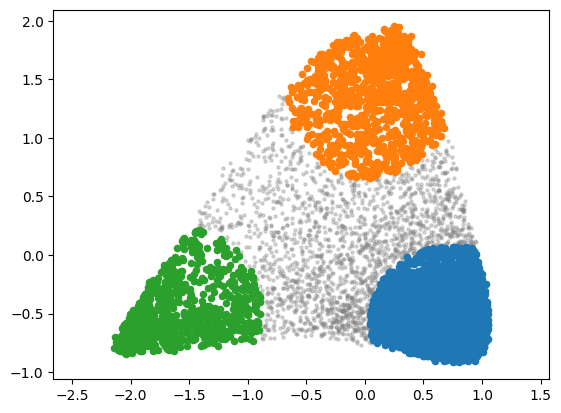

In [16]:
cluster_idx1 = np.where(cr[0] > 0.8)[0]
cluster_idx2 = np.where(cr[1] > 0.8)[0]
cluster_idx3 = np.where(cr[2] > 0.8)[0]

cluster_idxs = [cluster_idx1,cluster_idx2,cluster_idx3]

plt.scatter(-1*diff_dists[:,1],-1*diff_dists[:,2],s=5,c='grey',alpha=0.3,rasterized=True)
for i in range(3):
    plt.scatter(-1*diff_dists[cluster_idxs[i],1],-1*diff_dists[cluster_idxs[i],2],s=20,rasterized=True)
plt.axis('equal')
# plt.savefig(Fig_path+'/Diff_map_extremes.pdf')

In [96]:
cluster_idx1 = np.where(cr[0] > 0.8)[0]
cluster_idx2 = np.where(cr[1] > 0.8)[0]
cluster_idx3 = np.where(cr[2] > 0.8)[0]

cluster_idxs = [cluster_idx1,cluster_idx2,cluster_idx3]


n_state=3

P_groups = np.zeros((3, n_state, n_state))
lcs_conds = []
delay=2

for cf,g in enumerate(np.arange(3)):
    print(cf)
    idx = cluster_idxs[cf]
    print(len(idx))
    cluster_all = ma.concatenate(cluster_recs[idx],axis=0)
    segments = op_calc.segment_maskedArray(cluster_all)
    dtrajs = np.asarray([cluster_all[t0:tf] for t0,tf in segments],dtype=object)
    count_matrices = np.zeros((n_state,n_state))
    for d in dtrajs:
        count_matrices += op_calc.get_count_ms([d],delay,n_state).todense()
    P_groups[cf,:,:] = msm_estimation.transition_matrix(count_matrices)
    
    # lcs_cond, P_cond = op_calc.transition_matrix(dtrajs,delay=delay, return_connected=True)

0
2966
1
960
2
968


In [97]:
def polygon(sides, radius=1, rotation=0, translation=None):
    one_segment = np.pi * 2 / sides

    points = [
        (np.sin(one_segment * i + rotation) * radius,
         np.cos(one_segment * i + rotation) * radius)
        for i in range(sides)]

    if translation:
        points = [[sum(pair) for pair in zip(point, translation)]
                  for point in points]

    return points

from matplotlib import patches
def draw_curved_arrow(idx0,point0,point1,hw,angle,color_array):
    style = "Simple, tail_width={}, head_width={}, head_length={}".format(hw,5*hw,7.5*hw)
    kw = dict(arrowstyle=style, color=color_array[idx0])
    a = patches.FancyArrowPatch(point0, point1,
                                 connectionstyle="arc3,rad={}".format(angle), **kw)
    plt.gca().add_patch(a)

def get_angle_array(idx,n_states):
    idx=0
    angle_array = np.zeros(n_states)
    for k in range(3):
        angle_array[idx-k-1]=.3*kx+k*.05
        if idx+k>n_states-1:
            angle_array[k-n_states+idx] = -.3*kx-k*.05
        else:
            angle_array[idx+k]=-.35*kx-k*.01
    return angle_array



[0.00118663 0.97229383 0.02651954]


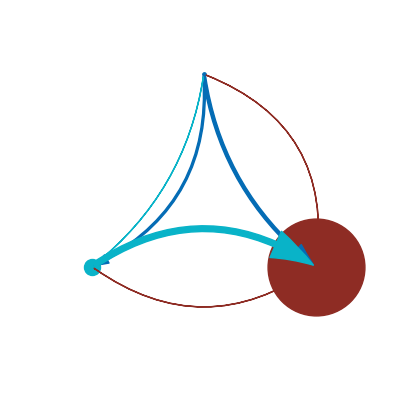

In [103]:
n_states=3
# st_colors = ['C0','C1','C2','C3','C4']
# st_colors = ['#8E2C24','#046CB5']
st_colors = ['#046CB5','#8E2C24','#09B3C8']

points = polygon(n_states)

Pc_d = copy.deepcopy(P_groups[2])
ih = op_calc.stationary_distribution(Pc_d)
print(ih)
# np.fill_diagonal(Pc_d, 0)
Pc_d[Pc_d<1e-6]=0
plt.figure(figsize=(5,5))
for k in range(n_states):
    plt.scatter(points[k][0],points[k][1],s=5000*ih[k],c=st_colors[k], zorder=0)
kx=-1
for idx in range(n_states):
    angle_array = get_angle_array(idx,n_states)*kx
    trans_indices = np.arange(0,n_states)
    trans_indices = trans_indices[trans_indices!=idx]
    for kj,j in enumerate(trans_indices):
        
        draw_curved_arrow(idx,points[idx],points[j],7.5*Pc_d[idx,j],angle_array[kj],st_colors)
    kx=kx*-1
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.axis('off')
# plt.savefig(Fig_path + '/tmat_clus3.pdf')
plt.show()


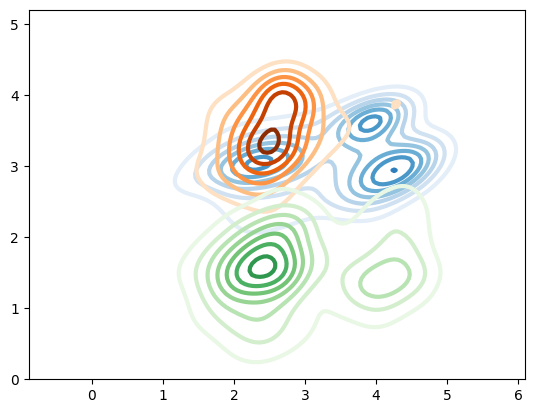

In [24]:
from scipy.stats import gaussian_kde
cmaps = ['Blues','Oranges','Greens']
fig, ax = plt.subplots(1,1)
rfp = np.log10(rfp_cher.compressed())
yfp = np.log10(yfp_cheb.compressed())
idx = np.where(dataset_idx == 0)[0]

# cluster_idx1 = np.nonzero(np.logical_and((diff_dists[idx,1]>0.0),(diff_dists[idx,2]<-0.003)))[0]
# cluster_idx2 = np.nonzero(np.logical_and((diff_dists[idx,1]>-0.01),(diff_dists[idx,2]>0.015)))[0]
# cluster_idx3 = np.nonzero(np.logical_and((diff_dists[idx,1]<-0.015),(diff_dists[idx,2]<0.00)))[0]
cluster_idx1 = np.where(cr[0][idx] > 0.8)[0]
cluster_idx2 = np.where(cr[1][idx] > 0.8)[0]
cluster_idx3 = np.where(cr[2][idx] > 0.8)[0]

cluster_idxs = [cluster_idx1,cluster_idx2,cluster_idx3]

for i in [0,1,2]:
    # img = stats.density_plot(rfp[cluster_idxs[i]], yfp[cluster_idxs[i]],[0,5],[0,5],50,50,smooth=True, border=3)
    # X,Y = np.meshgrid(np.linspace(0,5,56),np.linspace(1,5,56))
    # plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)
    values = np.vstack([rfp[cluster_idxs[i]], yfp[cluster_idxs[i]]])
    kernel = gaussian_kde(values,bw_method=0.32)
    X,Y = np.meshgrid(np.linspace(0,5.2,100),np.linspace(0,5.2,100))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3,vmax=0.5)
    # plt.colorbar()
# plt.xlim(0,5)
# plt.ylim(0,5)
plt.axis('equal')
# plt.savefig(Fig_path+'CherCheb_densities.pdf')
plt.show()

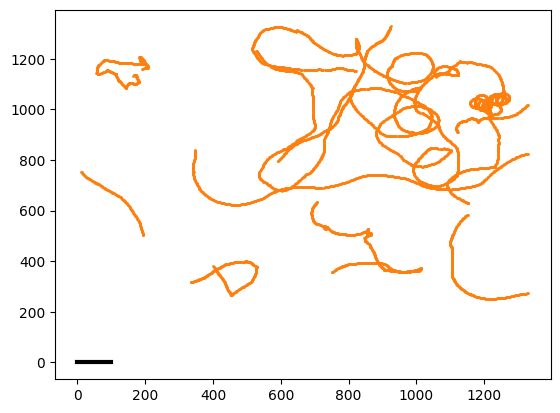

In [49]:
np.random.seed(42)
for j,i in enumerate(np.random.choice(cluster_idxs[0],10,replace=False)):
    plt.scatter((head_X_all[i,:,0]),(head_X_all[i,:,1]),s=1,color='C{}'.format(1))
plt.savefig(Fig_path+'cluster_1_egs.pdf')
for j,i in enumerate(np.random.choice(cluster_idxs[1],10,replace=False)):
    plt.scatter((head_X_all[i,:,0]),(head_X_all[i,:,1]),s=1,color='C{}'.format(1))
plt.savefig(Fig_path+'cluster_2_egs.pdf')
for j,i in enumerate(np.random.choice(cluster_idxs[2],10,replace=False)):
    plt.scatter((head_X_all[i,:,0]),(head_X_all[i,:,1]),s=1,color='C{}'.format(1))
plt.savefig(Fig_path+'cluster_3_egs.pdf')
# plt.show()

In [ ]:
idx=4

for clus in np.arange(1,4):
    f = h5py.File(path_to_filtered_data + 'sims/sims_lensim_5000_group_{}_{}.h5'.format(clus,idx),'r')
    X_sims = np.array(f['sims_gs_X'])
    f.close()
    plt.plot(X_sims[0][:5000,0],X_sims[0][:5000,1],c='C{}'.format(clus-1))
    # plt.plot(
    plt.axis('equal')
plt.show()

In [19]:
rmin=3.0
maxR = 5000.
dist_range = np.logspace(np.log10(rmin),np.log10(maxR),50)

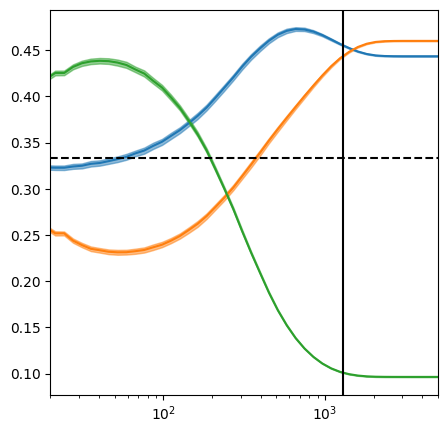

In [25]:
len_sim=1000
l_range = [10.,20.,30.]
for dr in [l_range[0]]:
    f = h5py.File(path_to_filtered_data + '/est_probs/bootstrap_detect_probs_groups_nbouts_{}_l_{:.2f}.h5'.format(len_sim,dr),'r')
    mean_ci = np.array(f['mean_ci'])
    dist_range = np.array(f['dist_range'])
    f.close()
    plt.figure(figsize=(5,5))
    # plt.title('dr = {:.2f},len_sim={}'.format(dr,len_sim))
    for clu in np.arange(3):
        mean = mean_ci[:,clu,0]
        cil = mean_ci[:,clu,1]
        ciu = mean_ci[:,clu,2]
        plt.plot(dist_range,mean, c='C{}'.format(clu))
        plt.fill_between(dist_range,cil,ciu,alpha=.5, color='C{}'.format(clu))

    # plt.ylim(0.1,.45)
    plt.axhline(1/3,c='k',ls='--')
    plt.xscale('log')
    plt.axvline(1300,c='k')
    plt.xlim(20,5000)
#     plt.savefig('detect_probs_dr_{:.2f}.pdf'.format(dr))
    # plt.yscale('log')
    plt.savefig(Fig_path + 'clus_detect_probs.pdf')
    plt.show()